# ML/Data Science Project - Classification

## Project outline

The aims of this project is to create a classification model that will allow us to predict the if a patient/individual has or has not had a stroke based off of certain feature variables- this can be useful in helping to predict whether or not a particular patient is at risk of suffering from a stroke in the near future. 

Data source: https://www.kaggle.com/datasets/jillanisofttech/brain-stroke-dataset  

### Models to be used

We can immediatly see that logistic regression can serve as an ideal model here as this model outputs probabilities. However, an underlying assumption with logistic regression is that the data itself shares a linear relationship with the target variable (as such, an alternative model, such as SVM or random forest  may be more reasonable). If this is the case, strategies to output probabilities from SVM or random forest models will be explored.

Regardless, even if an svm/random forest model is found to be more accurate, logistic regression will still be used as a baseline model in order to help facilitate better understanding of the dataset itself.

# EDA

In [201]:
# Importing libaries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [202]:
df = pd.read_csv('Processed_datasets/Brain Stroke/brain_stroke_data.csv')

In [203]:
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Female,46.0,0,0,Yes,Private,Urban,78.79,42.4,smokes,0
1,Female,65.0,0,0,Yes,Self-employed,Urban,248.24,27.0,smokes,0
2,Male,70.0,1,0,Yes,Self-employed,Rural,118.81,26.0,smokes,0
3,Male,47.0,0,0,Yes,Private,Urban,111.84,33.7,Unknown,0
4,Male,31.0,0,0,Yes,Govt_job,Urban,65.70,30.4,formerly smoked,0


In [204]:
df.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

In [205]:
df.dtypes

gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object

In [206]:
df.shape

(4482, 11)

In [207]:
df.describe()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,4482.000000,4482.000000,4482.000000,4482.000000,4482.000000,4482.000000
mean,43.446693,0.098394,0.054663,105.761430,28.466064,0.049755
std,22.592327,0.297879,0.227347,44.943627,6.764658,0.217462
min,0.080000,0.000000,0.000000,55.120000,14.000000,0.000000
25%,26.000000,0.000000,0.000000,77.192500,23.600000,0.000000
50%,45.000000,0.000000,0.000000,91.680000,28.100000,0.000000
75%,61.000000,0.000000,0.000000,113.637500,32.575000,0.000000
max,82.000000,1.000000,1.000000,267.760000,48.900000,1.000000


In [208]:
#checking what are the unique answers for the categorical data

print(df['gender'].unique())
print(df['ever_married'].unique())
print(df['work_type'].unique())
print(df['Residence_type'].unique())
print(df['smoking_status'].unique())

['Female' 'Male']
['Yes' 'No']
['Private' 'Self-employed' 'Govt_job' 'children']
['Urban' 'Rural']
['smokes' 'Unknown' 'formerly smoked' 'never smoked']


In [209]:
#checking the data balance

print(df['stroke'].value_counts(),'\n')
print(df['gender'].value_counts(),'\n')
print(df['ever_married'].value_counts(),'\n')
print(df['work_type'].value_counts(),'\n')
print(df['Residence_type'].value_counts(),'\n')
print(df['smoking_status'].value_counts(),'\n')
print(df['hypertension'].value_counts(),'\n')
print(df['heart_disease'].value_counts())

stroke
0    4259
1     223
Name: count, dtype: int64 

gender
Female    2600
Male      1882
Name: count, dtype: int64 

ever_married
Yes    2951
No     1531
Name: count, dtype: int64 

work_type
Private          2571
Self-employed     721
children          602
Govt_job          588
Name: count, dtype: int64 

Residence_type
Urban    2282
Rural    2200
Name: count, dtype: int64 

smoking_status
never smoked       1665
Unknown            1352
formerly smoked     759
smokes              706
Name: count, dtype: int64 

hypertension
0    4041
1     441
Name: count, dtype: int64 

heart_disease
0    4237
1     245
Name: count, dtype: int64


In [ ]:
#checking for nulls
df.isnull().sum()

gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

In [ ]:
#Checking for duplicates
df.duplicated().sum()

np.int64(0)

### Initial comments:

- We can see from the above that we have ten feature variables and 4482 examples. We can immediately see that many of the features will require one hot encoding prior to training. Moreover, numerical features will also have to be normalised. 

- From my initial thoughts, prior to doing any visual analysis, the 'ever_married' column do not seem too relevant wrt to predicting the liklihood of stroke- even if the models show that it is a strong indicator for stroke, we will still have to investigate there is genuine reason to believe that they have a causal relationship.

- One of the possible answers for 'smoking_status' is Unknown. Should keep an eye out for this when visually exploring the data. Overall, the different elements in this feature seem fairly balanced.

- No null values in the dataset.

- Data is extremely inbalanced as we might expect- most do not have strokes. However, this demands that we carefully tune our model in order for it to be of any use (based off of this dataset alone, predicting that absolutly no one will have /has had a stroke will yield an accuracy of 95%). Thus, we need to look at other metrics other than accuracy such as the True positive  rate. We may need to also consider upsampling/downsampling the data to achieve more balance. Lastly, we notice that hypertension and heart disease seem to also be unbalanced, and the next section reveals average glucose levels to be unbalanced too.

### Graphing

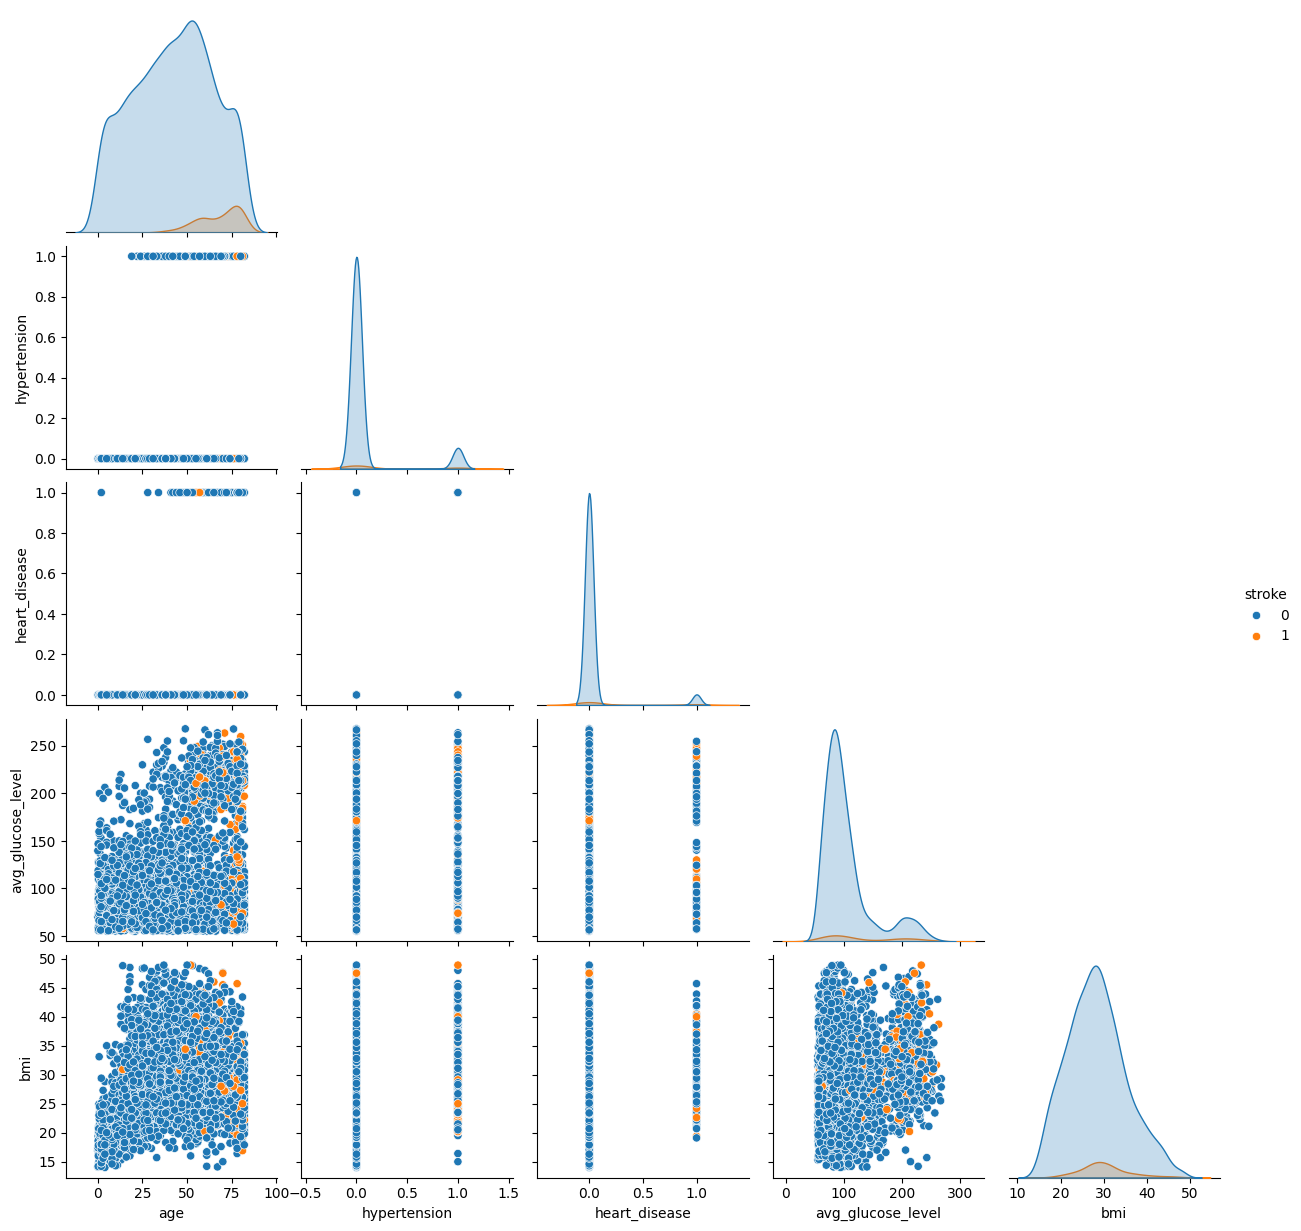

In [211]:
#pairplot
sns.pairplot(df, hue='stroke',corner=True)

<Axes: >

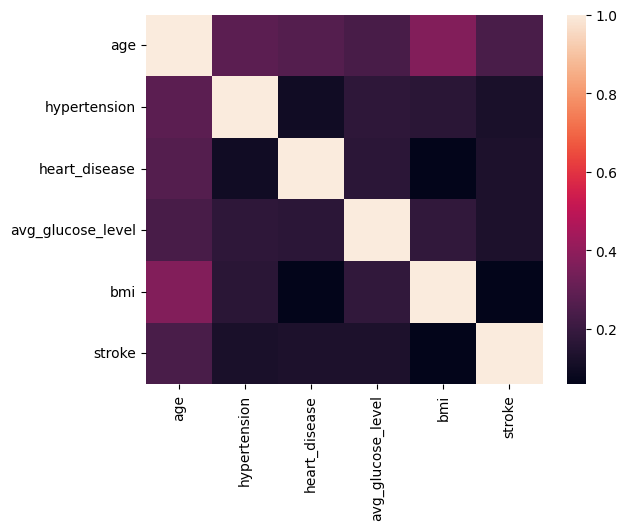

In [212]:
#correlation heatmap
sns.heatmap(df.corr(numeric_only=True))

<Axes: >

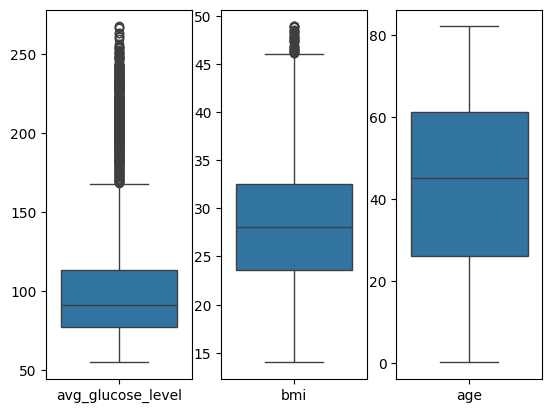

In [213]:
#Boxplots

#define dimensions of subplots (rows, columns)
fig, axes = plt.subplots(1, 3)

#create chart in each subplot
sns.boxplot(data=df[['avg_glucose_level']], ax=axes[0])
sns.boxplot(data=df[['bmi']], ax=axes[1])
sns.boxplot(data=df[['age']], ax=axes[2])

<Axes: ylabel='Count'>

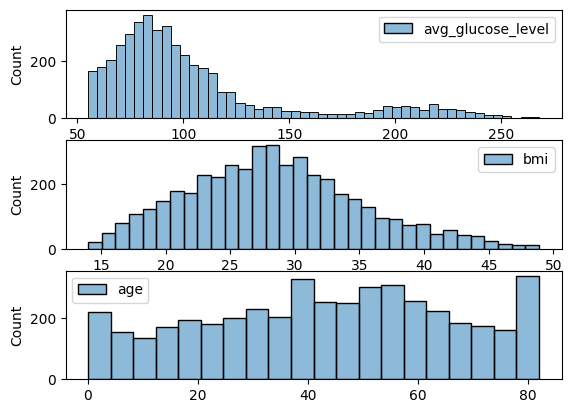

In [214]:
#Histograms

#define dimensions of subplots (rows, columns)
fig, axes = plt.subplots(3, 1)

#create chart in each subplot
sns.histplot(data=df[['avg_glucose_level']], ax=axes[0])
sns.histplot(data=df[['bmi']], ax=axes[1])
sns.histplot(data=df[['age']], ax=axes[2])

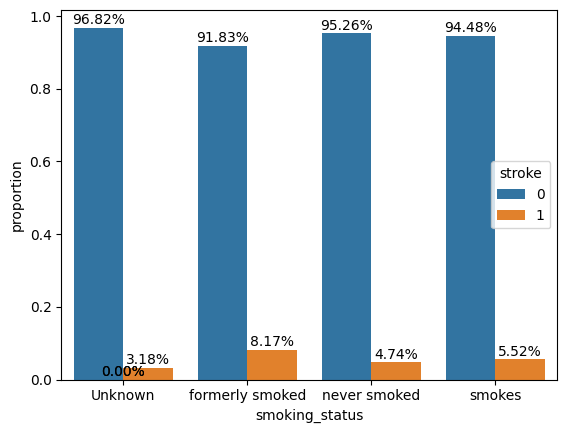

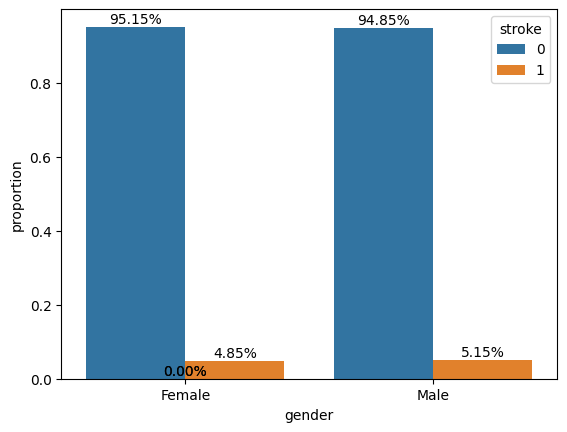

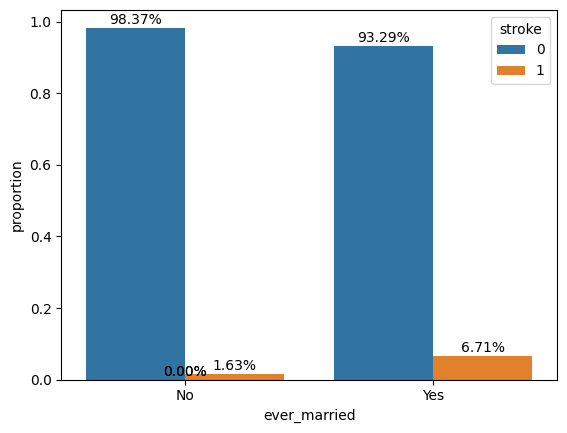

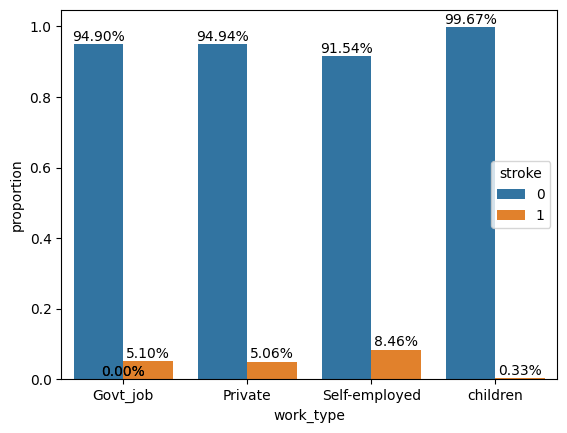

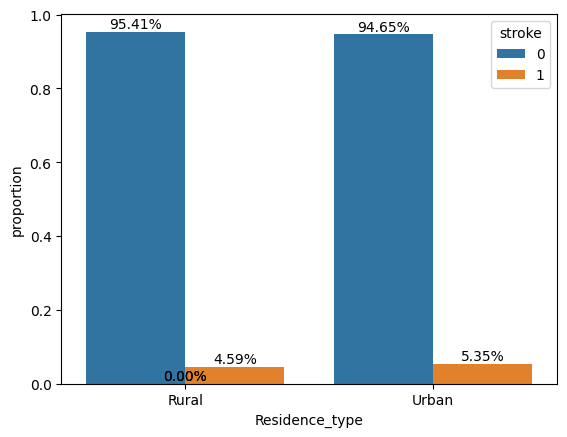

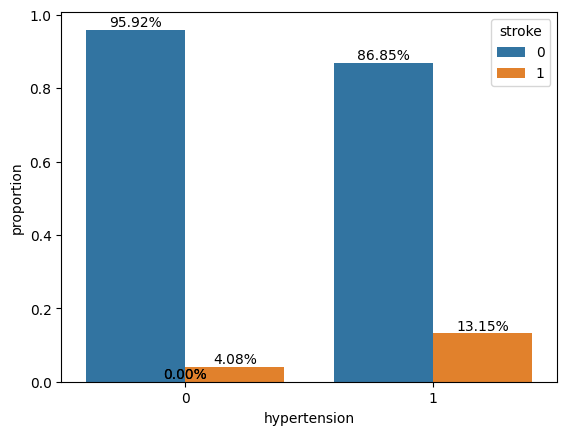

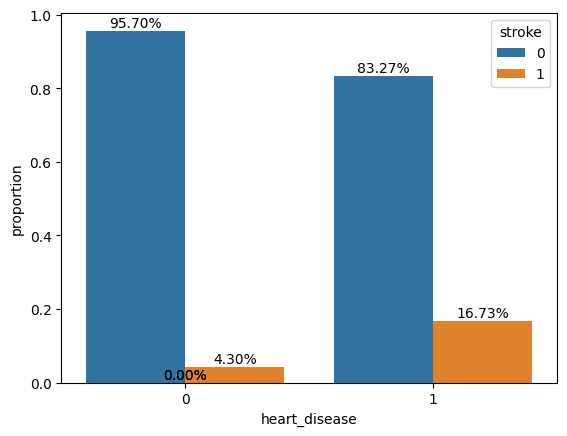

In [215]:
#Count graphs showing the ratio of strokes and no stroke for each element in all the categorical features.
# Note: graphs are normalised for element ascirbed by the hue to make comparisons more easier.

# smoking_status vs stroke
grouped_data_smoke = df.groupby(['smoking_status', 'stroke']).size().reset_index(name='counts')
grouped_data_smoke['total'] = grouped_data_smoke.groupby('smoking_status')['counts'].transform('sum')
grouped_data_smoke['proportion'] = grouped_data_smoke['counts'] / grouped_data_smoke['total']

ax = sns.barplot(x="smoking_status", y="proportion", hue="stroke", data=grouped_data_smoke)
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2, height + 0.01, f'{height:.2%}', ha="center")
plt.show()


# gender vs stroke
grouped_data_gender = df.groupby(['gender', 'stroke']).size().reset_index(name='counts')
grouped_data_gender['total'] = grouped_data_gender.groupby('gender')['counts'].transform('sum')
grouped_data_gender['proportion'] = grouped_data_gender['counts'] / grouped_data_gender['total']

ax = sns.barplot(x="gender", y="proportion", hue="stroke", data=grouped_data_gender)
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2, height + 0.01, f'{height:.2%}', ha="center")
plt.show()


# ever_married vs stroke
grouped_data_married = df.groupby(['ever_married', 'stroke']).size().reset_index(name='counts')
grouped_data_married['total'] = grouped_data_married.groupby('ever_married')['counts'].transform('sum')
grouped_data_married['proportion'] = grouped_data_married['counts'] / grouped_data_married['total']

ax = sns.barplot(x="ever_married", y="proportion", hue="stroke", data=grouped_data_married)
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2, height + 0.01, f'{height:.2%}', ha="center")
plt.show()


# work_type vs stroke
grouped_data_work = df.groupby(['work_type', 'stroke']).size().reset_index(name='counts')
grouped_data_work['total'] = grouped_data_work.groupby('work_type')['counts'].transform('sum')
grouped_data_work['proportion'] = grouped_data_work['counts'] / grouped_data_work['total']

ax = sns.barplot(x="work_type", y="proportion", hue="stroke", data=grouped_data_work)
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2, height + 0.01, f'{height:.2%}', ha="center")
plt.show()


# Residence_type vs stroke
grouped_data_res = df.groupby(['Residence_type', 'stroke']).size().reset_index(name='counts')
grouped_data_res['total'] = grouped_data_res.groupby('Residence_type')['counts'].transform('sum')
grouped_data_res['proportion'] = grouped_data_res['counts'] / grouped_data_res['total']

ax = sns.barplot(x="Residence_type", y="proportion", hue="stroke", data=grouped_data_res)
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2, height + 0.01, f'{height:.2%}', ha="center")
plt.show()


# hypertension vs stroke
grouped_data_hyp = df.groupby(['hypertension', 'stroke']).size().reset_index(name='counts')
grouped_data_hyp['total'] = grouped_data_hyp.groupby('hypertension')['counts'].transform('sum')
grouped_data_hyp['proportion'] = grouped_data_hyp['counts'] / grouped_data_hyp['total']

ax = sns.barplot(x="hypertension", y="proportion", hue="stroke", data=grouped_data_hyp)
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2, height + 0.01, f'{height:.2%}', ha="center")
plt.show()


# heart_disease vs stroke
grouped_data_hd = df.groupby(['heart_disease', 'stroke']).size().reset_index(name='counts')
grouped_data_hd['total'] = grouped_data_hd.groupby('heart_disease')['counts'].transform('sum')
grouped_data_hd['proportion'] = grouped_data_hd['counts'] / grouped_data_hd['total']

ax = sns.barplot(x="heart_disease", y="proportion", hue="stroke", data=grouped_data_hd)
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2, height + 0.01, f'{height:.2%}', ha="center")
plt.show()


<Axes: xlabel='bmi', ylabel='Percent'>

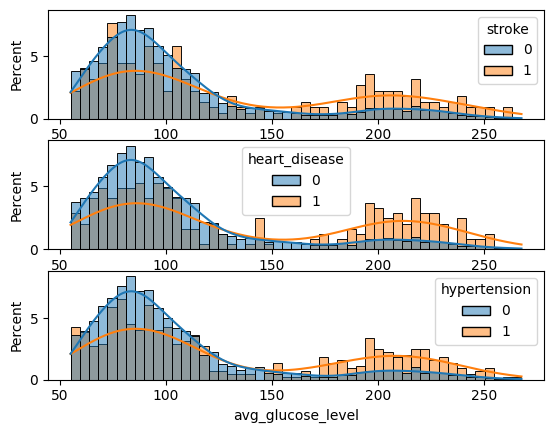

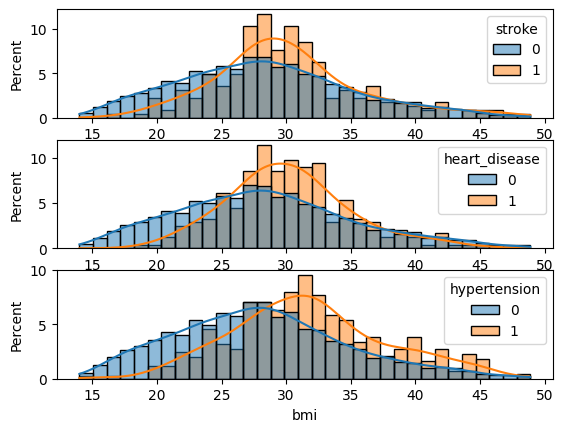

In [216]:
#More histograms

#define dimensions of subplots (rows, columns)
fig2, axes = plt.subplots(3,1)

#average glucose levels and stroke
sns.histplot(data = df, x='avg_glucose_level',kde=True, hue='stroke',stat='percent',common_norm=False, ax=axes[0])

#heart disease and average glucose levels 
sns.histplot(data = df, x='avg_glucose_level',kde=True, hue='heart_disease',stat='percent',common_norm=False, ax=axes[1])

#average glucose levels and hypertension
sns.histplot(data = df, x='avg_glucose_level',kde=True, hue='hypertension',stat='percent',common_norm=False, ax=axes[2])




#define dimensions of subplots (rows, columns)
fig4, axes = plt.subplots(3,1)

#average glucose levels and stroke
sns.histplot(data = df, x='bmi',kde=True, hue='stroke',stat='percent',common_norm=False, ax=axes[0])

#heart disease and average glucose levels 
sns.histplot(data = df, x='bmi',kde=True, hue='heart_disease',stat='percent',common_norm=False, ax=axes[1])

#average glucose levels and hypertension
sns.histplot(data = df, x='bmi',kde=True, hue='hypertension',stat='percent',common_norm=False, ax=axes[2])



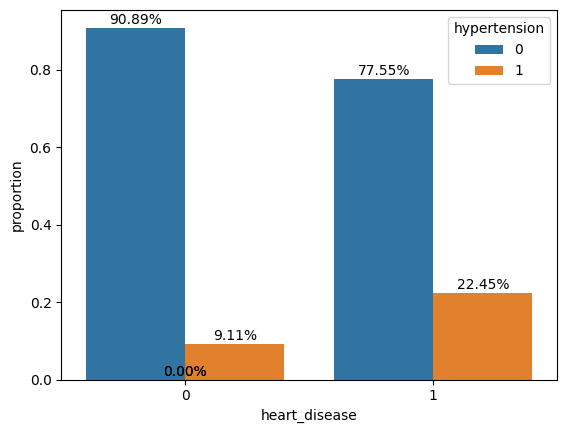

In [217]:
# heart disease vs hypertension countplot
grouped_data_hd = df.groupby(['heart_disease', 'hypertension']).size().reset_index(name='counts')
grouped_data_hd['total'] = grouped_data_hd.groupby('heart_disease')['counts'].transform('sum')
grouped_data_hd['proportion'] = grouped_data_hd['counts'] / grouped_data_hd['total']

ax = sns.barplot(x="heart_disease", y="proportion", hue="hypertension", data=grouped_data_hd, )
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2, height + 0.01, f'{height:.2%}', ha="center")

<Axes: xlabel='age', ylabel='Density'>

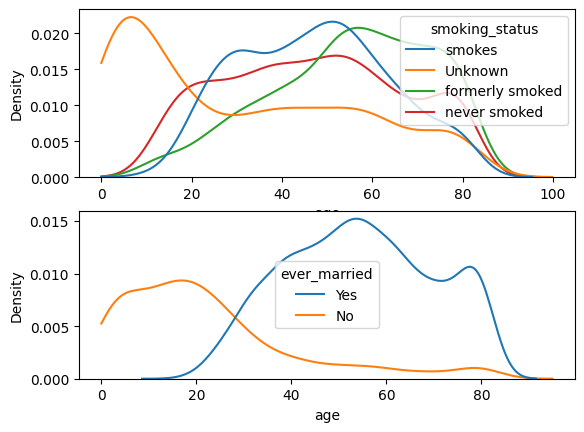

In [218]:
#kde plot of ages grouped by different smoking status and marriage status
fig3, axes = plt.subplots(2,1)
sns.kdeplot(data = df, x='age', hue='smoking_status', common_norm=False, clip=[0,100], ax = axes[0])
sns.kdeplot(data = df, x='age', hue='ever_married', clip=[0,100], ax = axes[1])

## EDA comments

### Avg_glucose level
The histogram above shows average glucose levels to be multimodal: the  value of the first peak resides around 80 whilst the second peak resides above 200. In addition, the boxplot considers the values above 150 (which is where the second peak begins to develop) to be outliers.

Glucose levels are most commonly known as blood sugar levels and serve as the primary predictor for diabetes. Referencing https://diabetesstrong.com/what-levels-of-blood-sugar-are-dangerous/, we can assume that the avg_glucose level has units mg/dl and that values above 200 are indicative of diabetes whilst values less than 140 are considered normal. According to https://www.diabetes.org.uk/about-diabetes/looking-after-diabetes/complications/stroke#Why%20does%20diabetes%20increase%20your%20risk%20of%20a%20stroke?, diabetes is linked to a greater chance of stroke as it hightens the risk of heart disease. We can conclude from this that these supposed outliers must be kept.

Unlike the kernel distribution plot for the ages in the pairplot, it is hard to see how the distribution for stroke vs no stroke varies as the stroke distribution is too small thus making it hard to see any differences- as such we plot the histogram again and ensure normalisation. What we see as a result is that for stroke patients, we see the multimodal distribution shape, however this time the peaks are almost equal in size, indicating that a higher glucose/ blood sugar level can be linked to a risk of stroke. 

### Hypertension and heart disease
Hypertension and heart disease are shown by the count plots to be the greatest predictors for stroke (13.2% and 16.7% respectivly). Furthermore, we see that both are related to each other when plotting the  kde distribution of average glocuse levels with the two (i.e. the peak at around 200 is much higher). Lastly, the barplot showing how proportion of heart disease varies with hypertension shows that these two together are also related. 

### BMI
The histogram for BMI shows a bell shaped distribution with a slight tail at the end. BMI levels above 45 seem to reperesent outliers, however contextually, a BMI above 45 represents morbid obesity which is linked to diabetes, heart problems and high blood pressure. As such, the outliers here do not have to be removed. 

The histogram/kde distribution plots further reveals that instances of stroke (to a slight extent), heart disease, hypertension (most noticably with hypertension) has its distribution located moreso towards higher bmi values. Whats more, the peaks are much higher for each of the graphs, indicating a stronger concentration of values near the mean.

### Age 
Distribution of ages seems to be fairly balanced in the dataset, with the age having a notable peak. The  kernel density estimation plot (see pairplot) for the ages clearly shows that stroke victims are much likly to be of individuals above at least 40. Furthermore, the distribution for stroke victims has a negative skew, whereas for people who have never had a stroke the distribution is more normal.

### smoking
In the countplots section, we see that smokers and never smokes do not seem to lead to a greater liklihood of stroke. We do however see that former smokers have a slighly higer proportion of individuals who have suffered from a stroke (8.17%). To investigate these two observations further, we plotted a kde plot of age grouped by the smoking status feature and normalised to make comparison easier. What we see revealed is interesting:
 - When looking at those who smoke versus those who have never smoked, we see that the kernel distributions for both are fairly similar and follow a normal distribution. 
 - The distribution for 'former smokers' has a negative skew - this explains the higher rate of stroke in this category as older age is an indicator for stroke as shown in the pair plot.
- The uknown element has an even stronger postive skew to younger ages, which likly reflects why the risk of stroke is much smaller for this category.


### Other features
- Gender and residence type: gender & residence type does not seem to be an indcator for stroke according to the countplots.

- ever married: 'ever married' has a significantly higher chance of stroke than never married (6.7% vs 1.6%). This however doesn't seem to have any causal link to stroke as the kde plot of age for the diffent elements in the ever_married feature shows that, as we might expect, people who have never married before are much more likly to be of a younger age and vice versa (above we have identified the relation between age and stroke risk).

- work_type: the count plot for work type shows that the element 'children' has a very small probability for stroke. In order to establish a causal link, we first need to know what this element means: does it refer to individuals who work with children or those who look after their children?

# Data preprocessing prior to training models

## One hot encoding

As hypertension, heart_disease, ever_married, gender and residence_type are binary features, we do need to one hot encode them. 

In [219]:
df_copy = df.copy(deep=True)

In [220]:
from sklearn.preprocessing import OneHotEncoder

categorical_features = ['work_type', 'smoking_status']
categorical_encoder = OneHotEncoder(sparse_output=False)

In [221]:
from sklearn.compose import ColumnTransformer
ct = ColumnTransformer(transformers=[
     ('cat', categorical_encoder, categorical_features)
     ])
# Get the encoded features as a pandas DataFrame
ct.set_output(transform='pandas')
encoded_features = ct.fit_transform(df)

In [222]:
from sklearn.preprocessing import LabelEncoder
# Encode the 'Color' column using label encoding

label_encoder1 = LabelEncoder()
label_encoder2 = LabelEncoder()
label_encoder3 = LabelEncoder()
encoded_label1 = label_encoder1.fit_transform(df['gender'])
encoded_label2 = label_encoder2.fit_transform(df['ever_married'])
encoded_label3 = label_encoder3.fit_transform(df['Residence_type'])
encoded_df = encoded_features.assign(gender=encoded_label1,ever_married=encoded_label2,Residence_type=encoded_label3)
encoded_df.head()


,cat__work_type_Govt_job,cat__work_type_Private,cat__work_type_Self-employed,cat__work_type_children,cat__smoking_status_Unknown,cat__smoking_status_formerly smoked,cat__smoking_status_never smoked,cat__smoking_status_smokes,gender,ever_married,Residence_type
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0,1,1
1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0,1,1
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1,1,0
3,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1,1,1
4,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1,1,1


In [223]:
df_copy.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Female,46.0,0,0,Yes,Private,Urban,78.79,42.4,smokes,0
1,Female,65.0,0,0,Yes,Self-employed,Urban,248.24,27.0,smokes,0
2,Male,70.0,1,0,Yes,Self-employed,Rural,118.81,26.0,smokes,0
3,Male,47.0,0,0,Yes,Private,Urban,111.84,33.7,Unknown,0
4,Male,31.0,0,0,Yes,Govt_job,Urban,65.70,30.4,formerly smoked,0


In [224]:
#concatenating it all together
df = pd.concat([encoded_df, df[['age','hypertension','heart_disease','avg_glucose_level','bmi','stroke']]],axis = 1)

In [228]:
#this gives us a list of what the encoded numbers (for binary categories) refer to
print('gender: ',label_encoder1.inverse_transform([0, 1]))
print('ever married: ',label_encoder2.inverse_transform([0, 1]))
print('residence type: ',label_encoder3.inverse_transform([0, 1]))

gender:  ['Female' 'Male']
ever married:  ['No' 'Yes']
residence type:  ['Rural' 'Urban']


## Normalisation
BMI, age and average glucose level will be normalised via z score scaling, as there distributions 

In [231]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [232]:
df[['age','avg_glucose_level','bmi']] = scaler.fit_transform(df[['age','avg_glucose_level','bmi']])

(array([[ 376.,  543.,  685.,  796.,  932.,  609.,  541.,    0.,    0.,
            0.],
        [   0.,  241., 1678., 1415.,  429.,  165.,  105.,  228.,  177.,
           44.],
        [ 220.,  535.,  830., 1057.,  876.,  481.,  265.,  162.,   56.,
            0.]]),
 array([-2.13871526, -1.56435515, -0.98999503, -0.41563492,  0.15872519,
         0.73308531,  1.30744542,  1.88180553,  2.45616565,  3.03052576,
         3.60488587]),
 <a list of 3 BarContainer objects>)

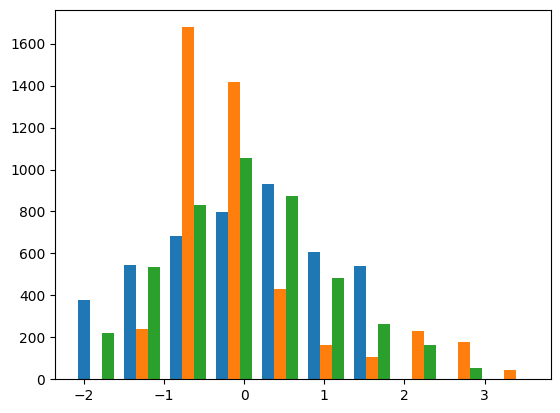

In [233]:
plt.hist(df[['age','avg_glucose_level','bmi']])

<Axes: xlabel='avg_glucose_level', ylabel='Count'>

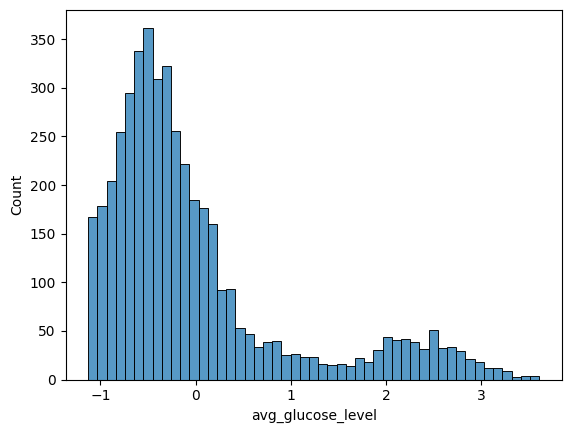

In [234]:
sns.histplot(df['avg_glucose_level'])

### preparing test data

In [ ]:
'''
df_test = pd.read_csv('Processed_datasets/Brain Stroke/brain_stroke_unseen.csv')

ct = ColumnTransformer(transformers=[
     ('cat', categorical_encoder, categorical_features)
     ])
# Get the encoded features as a pandas DataFrame
ct.set_output(transform='pandas')
encoded_features = ct.fit_transform(df_test)

label_encoder1 = LabelEncoder()
encoded_label1 = label_encoder1.fit_transform(df_test['gender'])
encoded_label2 = label_encoder2.fit_transform(df_test['ever_married'])
encoded_label3 = label_encoder3.fit_transform(df_test['Residence_type'])
encoded_df = encoded_features.assign(gender=encoded_label1,ever_married=encoded_label2,Residence_type=encoded_label3)

df_test = pd.concat([encoded_df, df_test[['age','hypertension','heart_disease','avg_glucose_level','bmi','stroke']]],axis = 1)

df_test[['age','avg_glucose_level','bmi']] = scaler.fit_transform(df_test[['age','avg_glucose_level','bmi']])

print('gender: ',label_encoder1.inverse_transform([0, 1]))
print('ever married: ',label_encoder2.inverse_transform([0, 1]))
print('residence type: ',label_encoder3.inverse_transform([0, 1]))

'''

## Sampling
We will train on the dataset as it is, and one dataset which is oversampled and see which results in a better model.

In [ ]:


from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.model_selection import train_test_split
X = df.iloc[:,:16]
y = df.iloc[:,-1]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

#Oversampling
print("Class distribution before SMOTE:", Counter(y_train))
smote = SMOTE(sampling_strategy='auto', random_state=42) #Oversampled with even balance
smote2 = SMOTE(sampling_strategy=0.5, random_state=42) #Oversampled with partially even balance
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
print("Class distribution after SMOTE (balanced data):", Counter(y_train_resampled))
X_train_resampled2, y_train_resampled2 = smote2.fit_resample(X_train, y_train)
print("Class distribution after SMOTE (balanced data):", Counter(y_train_resampled2))


Class distribution before SMOTE: Counter({0: 3405, 1: 180})
Class distribution after SMOTE (balanced data): Counter({0: 3405, 1: 3405})
Class distribution after SMOTE (balanced data): Counter({0: 3405, 1: 1702})


# model training

## Logistic regression (baseline)
Will test the original training dataset & and sampled datasets and compare them without parameters. Purpose of this logistic regression model is to reach a better understanding of the inference between the features and the target via looking at how weights are computed. Will use this as an oppertunity to see if oversampling via SMOTE results in a better model.

In [332]:
from sklearn.metrics import f1_score, classification_report 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score, log_loss, recall_score, precision_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import auc as sk_auc


def logistic(X,y,X_test = X_test, y_test = y_test):
    # Train a logistic regression model on the pumpkin dataset
    model = LogisticRegression()
    model.fit(X, y)
    predictions = model.predict(X_test)

    # Evaluate the model and print the results
    print(classification_report(y_test, predictions))
    

    print(confusion_matrix(y_test, predictions),'\n')
    print('log loss: ', log_loss(y_test,predictions),'\n')
    print('F1-score: ', f1_score(y_test, predictions),'\n')
    print('recall score :',recall_score(y_test,predictions),'\n')
    print('precision score :',precision_score(y_test,predictions),'\n')

    # Calculate AUC scores
    y_scores = model.predict_proba(X_test)
    auc = roc_auc_score(y_test,y_scores[:,1])
    print('Auc for ROC: ',auc)

    y_scores = model.predict_proba(X_test)[:, 1]
    precision, recall, thresholds = precision_recall_curve(y_test, y_scores)
    auc_score = sk_auc(recall, precision)
    print('Auc for PRC: ',auc_score,'\n')

    coef = model.coef_[0]
    print ('Coefficient scores for logistic regression:',coef)

    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, label=f'Precision-Recall Curve (AUC = {auc_score:.2f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend()
    plt.show()
    

c:\Users\rahma\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

c:\Users\rahma\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

c:\Users\rahma\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

c:\Users\rahma\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning:

Precision is ill-defined

              precision    recall  f1-score   support

           0       0.95      1.00      0.98       854
           1       0.00      0.00      0.00        43

    accuracy                           0.95       897
   macro avg       0.48      0.50      0.49       897
weighted avg       0.91      0.95      0.93       897

[[854   0]
 [ 43   0]] 

log loss:  1.7278451457436317 

F1-score:  0.0 

recall score : 0.0 

precision score : 0.0 

Auc for ROC:  0.8040139425957191
Auc for PRC:  0.12729932060275947 

Coefficient scores for logistic regression: [-0.1933478  -0.05684812 -0.36733206  0.60624788 -0.01612302  0.00785464
 -0.27046601  0.2674543  -0.03099628 -0.17058655  0.07725768  1.62293466
  0.42912423  0.22455523  0.20039351  0.06501756]


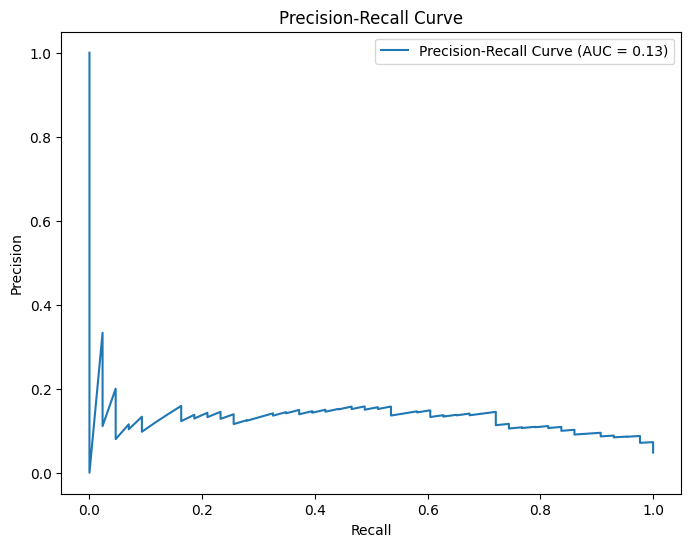

In [333]:
#training data on originally inbalanced dataset
logistic(X_train,y_train)

              precision    recall  f1-score   support

           0       0.98      0.74      0.84       854
           1       0.11      0.65      0.19        43

    accuracy                           0.73       897
   macro avg       0.54      0.69      0.51       897
weighted avg       0.94      0.73      0.81       897

[[629 225]
 [ 15  28]] 

log loss:  9.643786859964454 

F1-score:  0.1891891891891892 

recall score : 0.6511627906976745 

precision score : 0.11067193675889328 

Auc for ROC:  0.7807036653777027
Auc for PRC:  0.12323236539409493 

Coefficient scores for logistic regression: [-0.72608827 -0.1260817  -0.83217757  1.59531205 -0.27193115  0.08114535
 -0.41458851  0.51633882 -0.68988375 -0.58760313 -0.46690955  2.35868867
 -0.56310365 -0.62515608  0.21321599  0.19011277]


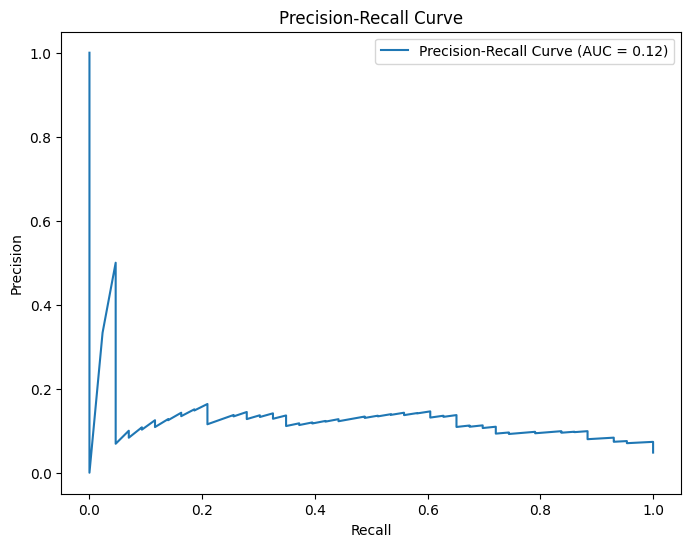

In [334]:
#Using oversampled dataset 
logistic(X_train_resampled,y_train_resampled)

              precision    recall  f1-score   support

           0       0.97      0.83      0.89       854
           1       0.14      0.56      0.22        43

    accuracy                           0.81       897
   macro avg       0.56      0.69      0.56       897
weighted avg       0.93      0.81      0.86       897

[[705 149]
 [ 19  24]] 

log loss:  6.750650801975119 

F1-score:  0.2222222222222222 

recall score : 0.5581395348837209 

precision score : 0.13872832369942195 

Auc for ROC:  0.7844343989978759
Auc for PRC:  0.12600892602637861 

Coefficient scores for logistic regression: [-0.81657338 -0.28950256 -0.82020262  1.45159972 -0.42693853  0.03417945
 -0.47874158  0.39682183 -0.60520251 -0.51415776 -0.34356229  2.1476083
 -0.47100269 -0.52276775  0.2369163   0.14983424]


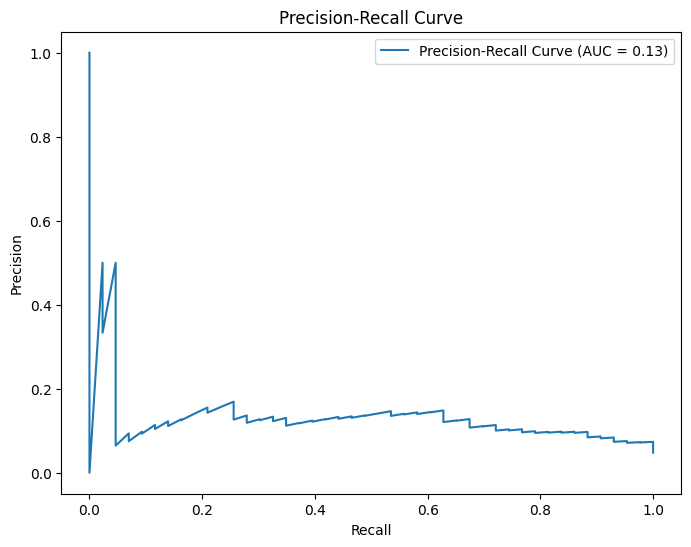

In [335]:
logistic(X_train_resampled2,y_train_resampled2)

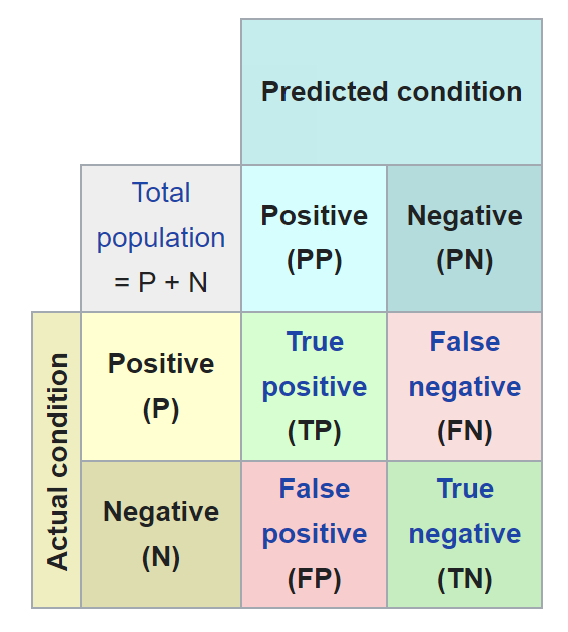

In [271]:
from turtle import width
from IPython import display
from base64 import b64decode
base64_data = '...'
display.Image(b64decode(base64_data), width=400, height=400)

In [336]:
y_test.value_counts()

stroke
0    854
1     43
Name: count, dtype: int64

### Logistic regression performance



With close inspection, we see that logistic regression models the data quite poorly. In the first model (which was trained on the inbalanced dataset), although we see a high accuracy (0.95), we can see just from the classification report alone that this model has simply predicted all patients in the test data to not have a stroke. As such the recall value is zero and thus this model is redundant.

When treating the class balance using SMOTE oversampling, we notice that the false negatives have been more than halved, resulting in a better recall (TPR ). Although ROC AUC score is slightly lower, we do see a much better PR AUC score (PR curve is much more relevant to us as our data is inbalanced). Despite the fact that we see PR AUC scores of around 0.12 (making it three times better than random), the plotted curve calls for concern as it does not follow what we usually expect. According to stackexchange, 'This would indicate a good detection of "strong" positive outcomes, but poor performance on the less clear candidates.' This perhaps reflects why we see many false positives in our current treshold value.